# Clasificador de vectores de soporte
Luego de calcular un baseline, se aplica un entrenamiento y clasificación de un modelo sencillo como lo es el clasificador de vectores de soporte, que nos servirá de modelo exploratorio.

Ya en el análisis preliminar de los datos se observó cierta superposición entre las distintas clases en prácticamente todos los features, por lo que automáticamente no se podría usar este clasificador con hard-margin. Avanzamos entonces con el clasificador de vectores de soporte con soft-margin, teniendo en cuenta que en realidad usando la librería de scikit-learn, el código no cambia.

In [1]:
import pandas as pd

## Tratamiento de datos

In [2]:
# Tratamiento de los datos
df = pd.read_csv('../dataset/star_classification.csv')
anomalias = df[(df['u'] == -9999) | (df['g'] == -9999) | (df['z'] == -9999)]

df = df[(df['u'] != -9999) & (df['g'] != -9999) & (df['z'] != -9999)]

In [3]:
from sklearn.model_selection import GroupShuffleSplit

gss = GroupShuffleSplit(test_size=0.2, n_splits=1, random_state=42)

train_idx, test_idx = next(gss.split(df, groups=df['obj_ID']))

train_df = df.iloc[train_idx]
test_df = df.iloc[test_idx]

features = ['alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'redshift']

X_train = train_df[features]
X_test = test_df[features]

y_train = train_df['class']
y_test = test_df['class']

In [4]:
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Entrenamiento SVC

In [5]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [6]:
# Probamos primero con un hiperparámtro C de ejemplo y kernel linear
svm_linear = SVC(C=10, kernel='linear')
svm_linear.fit(X_train_scaled, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",10
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


## Test

Text(0.5, 1.0, 'Matriz de confusión SVC Linear, C=10')

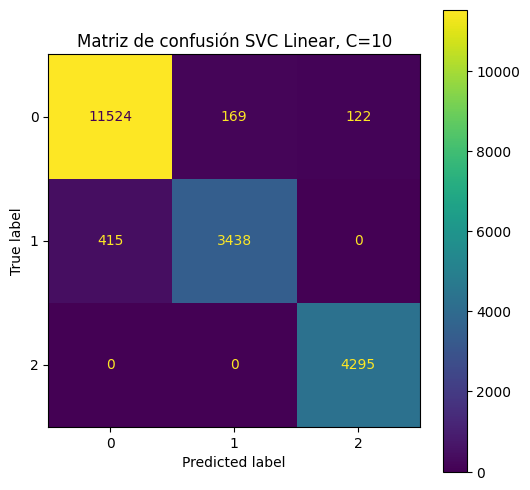

In [7]:
y_pred = svm_linear.predict(X_test_scaled)

cm = confusion_matrix(y_test, y_pred)

disp_cm = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=svm_linear.classes_
)

fig, ax = plt.subplots(figsize=(6, 6))
ax.grid = False
disp_cm.plot(ax=ax)
ax.set_title("Matriz de confusión SVC Linear, C=10")

In [13]:
from sklearn.metrics import accuracy_score, recall_score, f1_score
from sklearn.metrics import classification_report

print("Métricas de la clasificación")
print(classification_report(y_test, y_pred))
# print(f"Precisión: {accuracy_score(y_test, y_pred):.4f}")
# print(f"Recall: {recall_score(y_test, y_pred, average='weighted'):.4f}")
# print(f"F1 Score: {f1_score(y_test, y_pred, average='weighted'):.4f}")

Métricas de la clasificación
              precision    recall  f1-score   support

           0       0.97      0.98      0.97     11815
           1       0.95      0.89      0.92      3853
           2       0.97      1.00      0.99      4295

    accuracy                           0.96     19963
   macro avg       0.96      0.96      0.96     19963
weighted avg       0.96      0.96      0.96     19963



## Búsqueda de Hiperparámetros
Se aplica una búsqueda Bayesiana de hiperparámetros usando Optuna.

In [15]:
import optuna
from sklearn.model_selection import cross_val_score

In [16]:
def objective(trial):
    # Definir el espacio de búsqueda para los hiperparámetros
    C = trial.suggest_float('C', 1e-4, 1e5, log=True)
    kernel = trial.suggest_categorical('kernel', ['linear', 'poly', 'rbf', 'sigmoid'])

    # Algunos hiperparámetros dependen del kernel elegido
    if kernel in ['rbf', 'poly', 'sigmoid']:
        gamma = trial.suggest_categorical('gamma', ['scale', 'auto'])
    else:
        gamma = 'scale' # Valor por defecto para kernel lineal

    degree = trial.suggest_int('degree', 2, 5) if kernel == 'poly' else 3

    # Instanciar el modelo con los hiperparámetros sugeridos con la prueba actual
    clf = SVC(
        C=C, 
        kernel=kernel,
        gamma=gamma,
        degree=degree,
        random_state=42
    )

    # Evaluar el modelo, usando validación cruzada
    scores = cross_val_score(clf, X_train_scaled, y_train, cv=5, scoring='accuracy', n_jobs=-1)

    # Devolver la métrica a optimizar
    return scores.mean()

In [ ]:
# Dirección: maximizar la métrica elegida (accuracy)
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50)

print("Mejores hiperparámetros encontrados:", study.best_params)
print("Mejor puntuación de validación cruzada:", study.best_value)

[I 2026-04-18 21:44:09,982] A new study created in memory with name: no-name-b1d19587-8e54-4984-bda5-d5a0ae301041
[I 2026-04-18 21:47:18,768] Trial 0 finished with value: 0.8037259108310529 and parameters: {'C': 0.002632833419046989, 'kernel': 'sigmoid', 'gamma': 'scale'}. Best is trial 0 with value: 0.8037259108310529.
[I 2026-04-18 21:50:57,342] Trial 1 finished with value: 0.7382677788674851 and parameters: {'C': 0.0006945332108238497, 'kernel': 'sigmoid', 'gamma': 'auto'}. Best is trial 0 with value: 0.8037259108310529.
[I 2026-04-18 21:51:58,676] Trial 2 finished with value: 0.9619546203970547 and parameters: {'C': 13.109740224797957, 'kernel': 'linear'}. Best is trial 2 with value: 0.9619546203970547.


In [ ]:
# Entrenar un nuevo modelo con los mejores hiperparámetros encontrados
best_svm = SVC(**study.best_params, random_state=42)
best_svm.fit(X_train_scaled, y_train)

# Evaluar en test con este nuevo modelo
y_pred = best_svm.predict(X_test_scaled)

cm = confusion_matrix(y_test, y_pred)

disp_cm = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=svm_linear.classes_
)

fig, ax = plt.subplots(figsize=(6, 6))
ax.grid = False
disp_cm.plot(ax=ax)
ax.set_title("Matriz de confusión SVC optimizado")

print("Métricas de la clasificación")
print(classification_report(y_test, y_pred))